In [4]:
import os
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import glob
import re


In [34]:
def tflog2pandas(path, filter_tags=None):
    runlog_data = pd.DataFrame()
    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()

    tags = ea.Tags()['scalars']

    for tag in tags:
        if filter_tags is not None and tag not in filter_tags:
            continue
        event_list = ea.Scalars(tag)
        values = [e.value for e in event_list]
        steps = [e.step for e in event_list]
        tag_df = pd.DataFrame({tag: values, 'step': steps})
        
        if runlog_data.empty:
            runlog_data = tag_df
        else:
            runlog_data = pd.merge(runlog_data, tag_df, on="step", how="outer")

    return runlog_data


In [35]:
dftrain = tflog2pandas("./runs/supervised/final_model/train", ["Loss"])
dfvalidation = tflog2pandas("./runs/supervised/final_model/validation", ["Loss"])

In [29]:
plt.style.use("science")

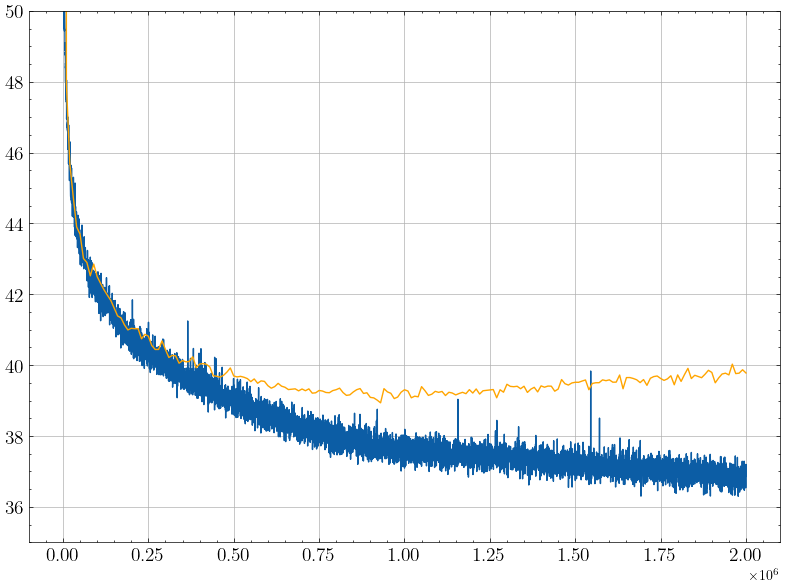

In [37]:
plt.figure(figsize=(8, 6))
plt.plot(dftrain["step"], dftrain["Loss"], label="train")
plt.plot(dfvalidation["step"], dfvalidation["Loss"], label="test", c="orange")
plt.ylim((35, 50))
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.show()

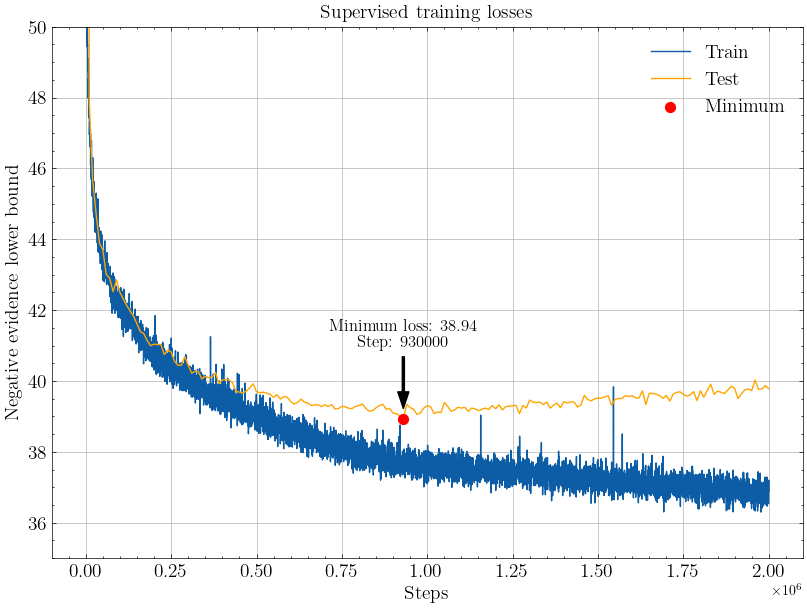

In [ ]:
min_loss_idx = dfvalidation["Loss"].idxmin()
min_step = dfvalidation.loc[min_loss_idx, "step"]
min_loss = dfvalidation.loc[min_loss_idx, "Loss"]

plt.figure(figsize=(8, 6))
plt.plot(dftrain["step"], dftrain["Loss"], label="Train")
plt.plot(dfvalidation["step"], dfvalidation["Loss"], label="Test", c="orange")

plt.scatter(min_step, min_loss, color="red", s=50, zorder=5, label="Minimum")

plt.annotate(
    f"Minimum loss: {min_loss:.2f}\nStep: {min_step}", 
    xy=(min_step, min_loss + 0.2), 
    xytext=(min_step, min_loss + 2),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1.5, headwidth=8),
    fontsize=12,
    ha="center"
)

plt.ylim((35, 50))
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.xlabel("Steps", fontsize=14)
plt.ylabel("Negative evidence lower bound", fontsize=14)
plt.title("Supervised training losses", fontsize=14)
plt.grid()
# plt.savefig("Training_loss.pdf")
plt.show()


In [9]:
folder_path = "Generate_positions/final_model/supervised/training_progress/train_no_move_last"
columns_to_plot = ["is_legal", "is_puzzle", "counter_intuitive", "themes_match"]

file_pattern = os.path.join(folder_path, 'model_*.csv')
file_paths = glob.glob(file_pattern)

data_points = [{"Legal rate": 0, "Uniqueness rate": 0, "Counter intuitive rate given unique": 0, "Puzzle rate": 0, "model_number": 0}]
for file in file_paths:
    filename = os.path.basename(file)
    match = re.search(r'model_(\d+)\.csv', filename)
    
    if match:
        model_number = int(match.group(1))        
        df = pd.read_csv(file, usecols=columns_to_plot)
        # means = df.mean().to_dict()
        means = {"Legal rate": 100 * df["is_legal"].mean(), "Uniqueness rate": 100 * df["is_puzzle"].mean(), "Counter intuitive rate given unique": 100 * df[df["is_puzzle"]]["counter_intuitive"].mean(), "Puzzle rate": 100 * (df["is_puzzle"] & df["counter_intuitive"]).mean()}
        means["model_number"] = model_number
        data_points.append(means)

df = pd.DataFrame(data_points)
df = df.sort_values("model_number")
# print(df)


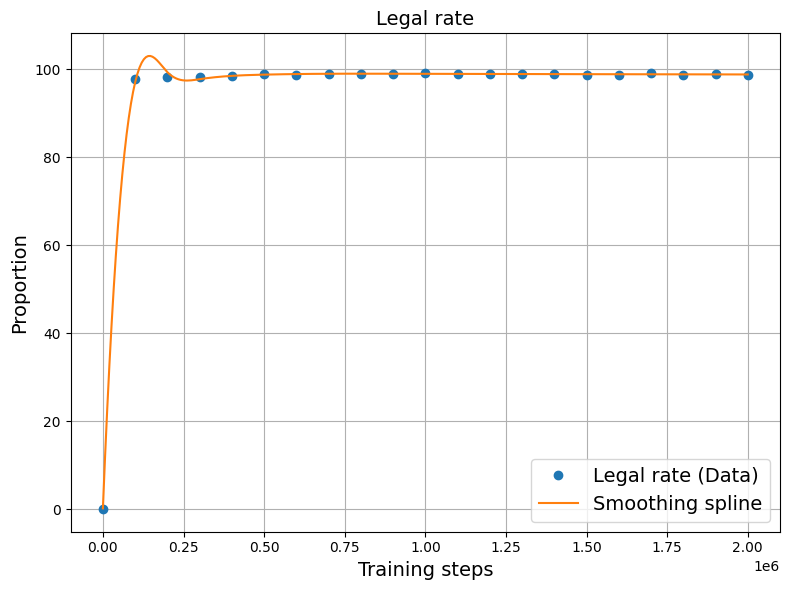

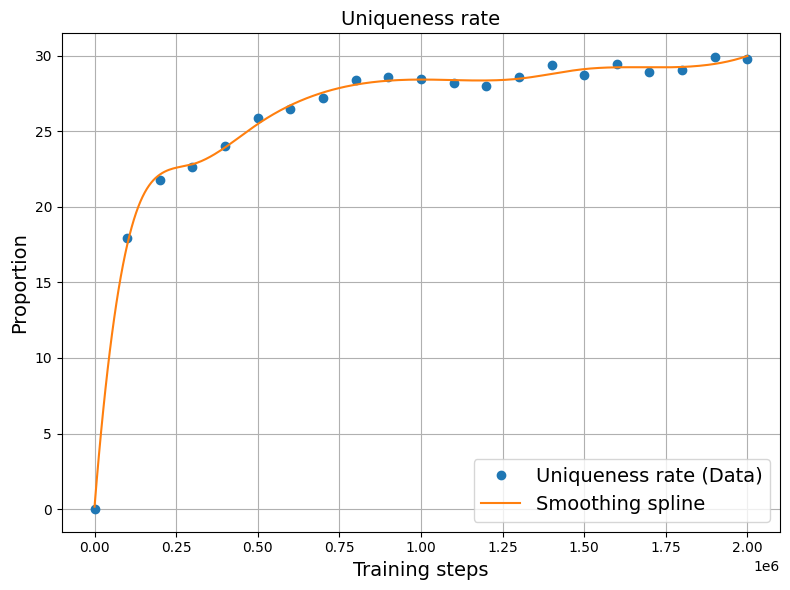

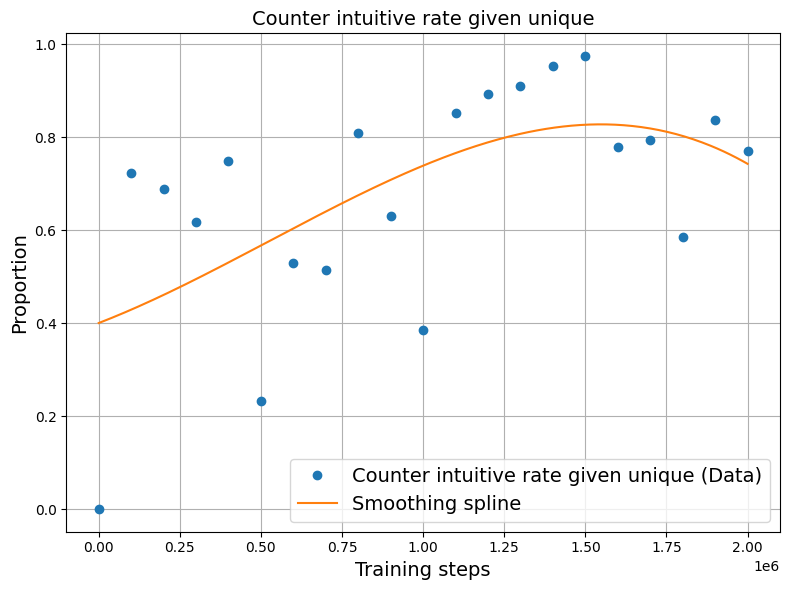

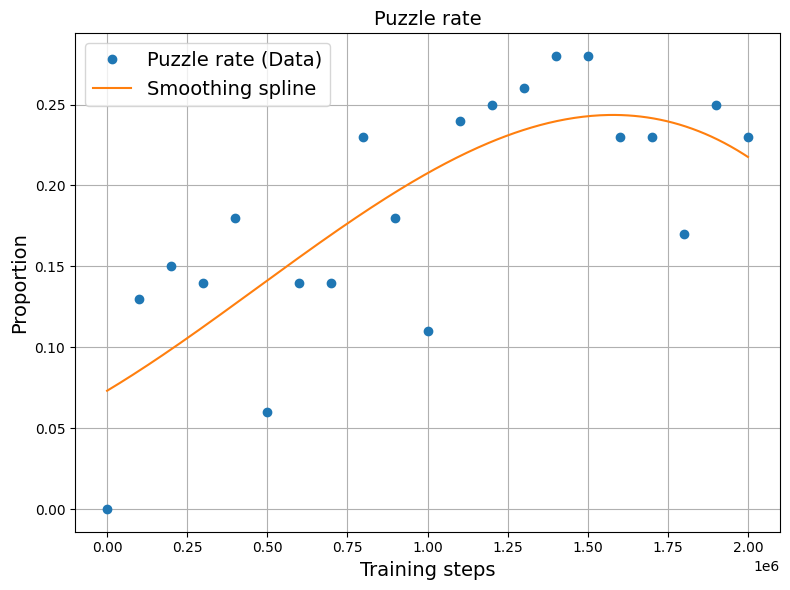

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline, make_splrep


for col in df.drop("model_number", axis=1).columns:
    plt.figure(figsize=(8, 6))
    
    x = df["model_number"]
    y = df[col]
    
    plt.plot(x, y, marker="o", linestyle="", label=f"{col} (Data)", c="tab:blue")

    # spline = make_interp_spline(x, y, k=3)
    smoothing_factor = 2
    spline = make_splrep(x, y, s=smoothing_factor)
    x_smooth = np.linspace(x.min(), x.max(), 300)
    y_smooth = spline(x_smooth)
    
    plt.plot(x_smooth, y_smooth, linestyle="-", color="tab:orange", label="Smoothing spline")
    plt.xlabel("Training steps", fontsize=14)
    plt.ylabel("Proportion", fontsize=14)
    plt.title(col, fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    
    plt.savefig(f"../Thesis/sections/figures/supervised_training_progress/{col.replace(" ", "_")}.pdf")
    plt.show()


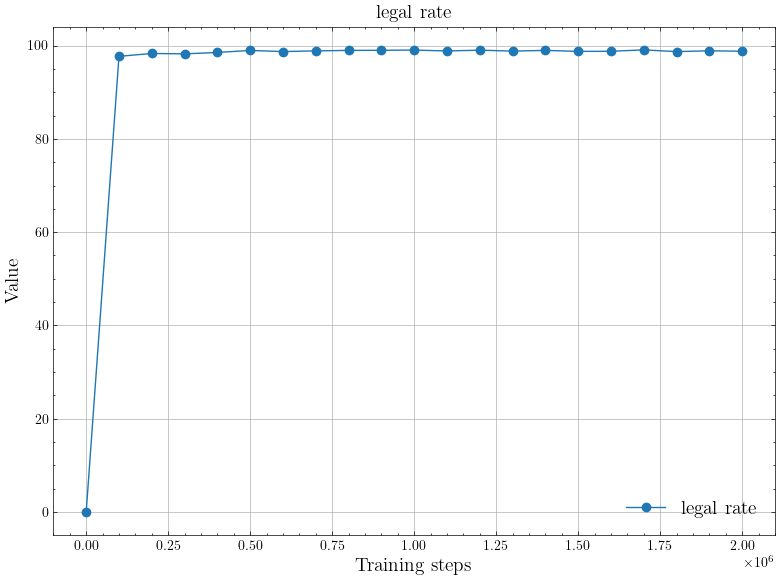

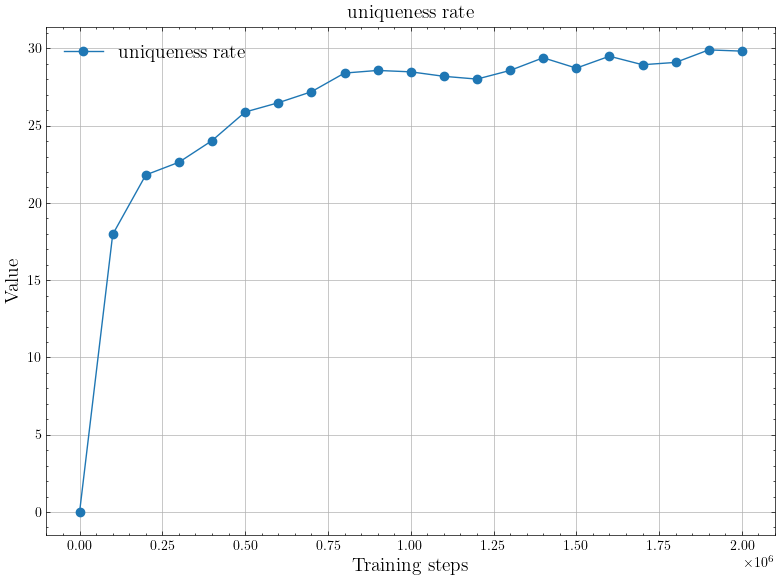

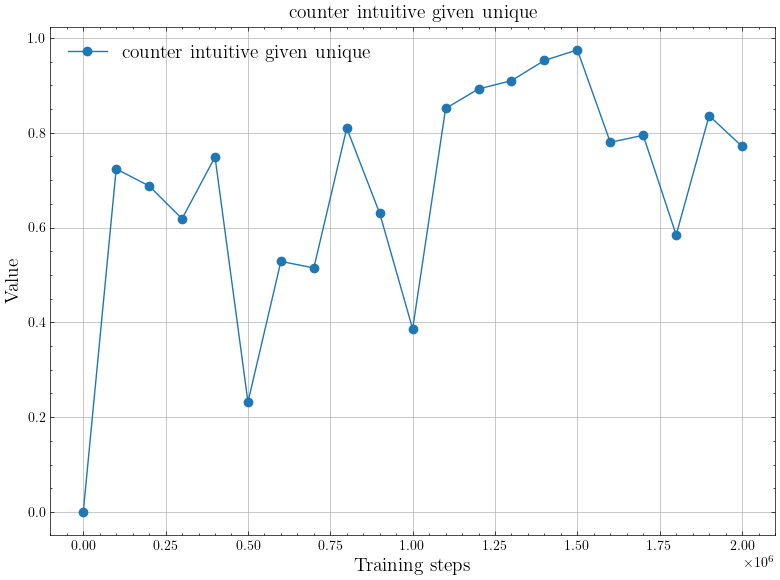

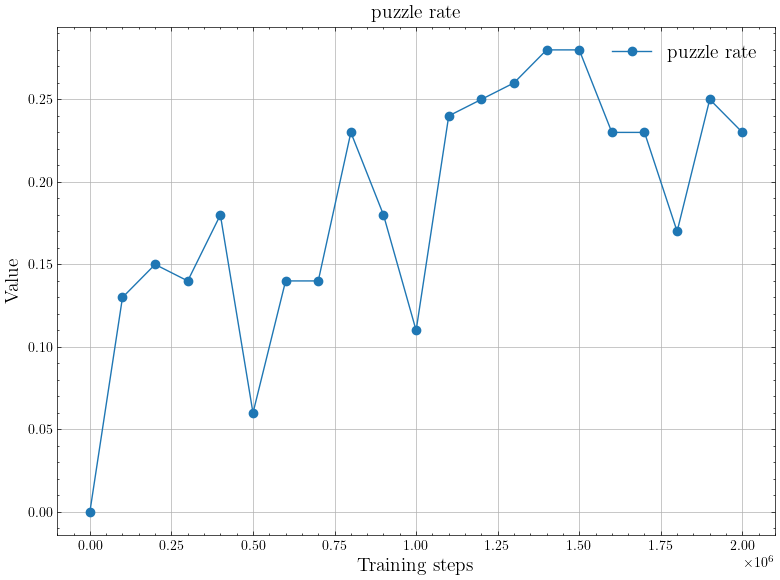

In [ ]:
for col in df.drop("model_number", axis=1).columns:
    plt.figure(figsize=(8, 6))
    plt.plot(df["model_number"], df[col], marker="o", linestyle="-", label=col, c="tab:blue")
    plt.xlabel("Training steps", fontsize=14)
    plt.ylabel("Value", fontsize=14)
    plt.title(col, fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig(f"../Thesis/sections/figures/{re.sub(r" ", "_", col)}")
    plt.show()

In [3]:
# log_path = "../src/runs/rl/espov3/run8"
# log_path = "../src/runs/rl/final_large_runs/no_conditioning/run2"
# log_path = "../src/runs/rl/final_large_runs/conditioning_with_move/run2"
log_path = "../src/runs/rl/final_large_runs/ESPO-ptx/run6"
# log_path = "../src/runs/rl/final_large_runs/test/run5"
df = tflog2pandas(log_path)
df.index = range(len(df))

In [4]:
df

,Components/legal_rate,step,Components/uniqueness_rate,Components/counter_intuitive_rate,Components/counter_intuitive_rate_given_unique,Components/unique_and_counter_intuitive,Components/entropy,Components/piece_counts,Components/dist_inter_fen,Components/dist_intra_fen,...,Components/all_dist,Components/pass_diversity_filtering,Components/move_match_rate,Components/cp_loss,Loss/Total Loss,Loss/RL Grad Norm,Loss/KL divergence,Loss/Clips,Loss/learning_rate,Reward
0,1.00000,0,0.09375,0.43750,0.000000,0.00000,0.556956,1.000000,14.531250,18.531250,...,0.281250,1.00000,0.531250,0.000000,0.004892,0.006596,2.539045e-07,0.0,0.000003,0.00000
1,1.00000,1,0.53125,0.25000,0.058824,0.03125,0.528086,0.968750,12.593750,15.468750,...,0.218750,0.84375,0.781250,38.000000,0.003328,0.179762,2.702679e-03,0.0,0.000003,0.03125
2,1.00000,2,0.18750,0.21875,0.166667,0.03125,0.589095,0.937500,15.437500,19.562500,...,0.343750,0.93750,0.687500,133.166672,0.004025,0.138358,1.255826e-03,0.0,0.000003,0.03125
3,1.00000,3,0.18750,0.31250,0.166667,0.03125,0.602986,0.968750,14.281250,17.718750,...,0.375000,0.90625,0.531250,74.166664,0.004119,0.137938,8.732797e-04,0.0,0.000003,0.03125
4,1.00000,4,0.25000,0.31250,0.000000,0.00000,0.623162,0.937500,15.000000,18.437500,...,0.343750,0.93750,0.656250,0.000000,0.004674,0.004511,7.666353e-05,0.0,0.000003,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1131,0.96875,1131,0.18750,0.34375,0.166667,0.03125,0.590833,0.967742,15.096774,18.451612,...,0.129032,0.83871,0.612903,0.000000,0.002177,0.586597,2.304044e-02,0.0,0.000003,-0.03125
1132,1.00000,1132,0.18750,0.31250,0.000000,0.00000,0.651795,1.000000,14.593750,18.187500,...,0.281250,0.93750,0.687500,144.666672,0.004890,0.118932,1.486730e-02,0.0,0.000003,0.00000
1133,1.00000,1133,0.34375,0.31250,0.000000,0.00000,0.572031,1.000000,15.187500,17.625000,...,0.406250,0.87500,0.468750,53.700001,0.005071,0.053696,8.356947e-03,0.0,0.000003,0.00000
1134,0.93750,1134,0.40625,0.21875,0.000000,0.00000,0.665119,0.966667,14.633333,18.766666,...,0.400000,0.90000,0.700000,0.000000,0.016010,0.842387,1.920290e+00,0.0,0.000003,-0.12500


In [ ]:
def plot_rolling(col: pd.DataFrame, window=100):
    col.rolling(window=window, win_type='gaussian').mean(std=window / 4).plot(title=col.name)

def plot_ema(col, alpha=0.001, start=0):
    col.ewm(alpha=alpha).mean().iloc[start:].plot(title=col.name)

def plot_all(df: pd.DataFrame, *args, window=100, alpha=0.001, start=0, type="rolling"):
    for col in df:
        plt.figure()
        if type == "rolling":
            plot_rolling(df[col], window=window)
        elif type == "ema":
            plot_ema(df[col], alpha=alpha, start=start)
    plt.show()

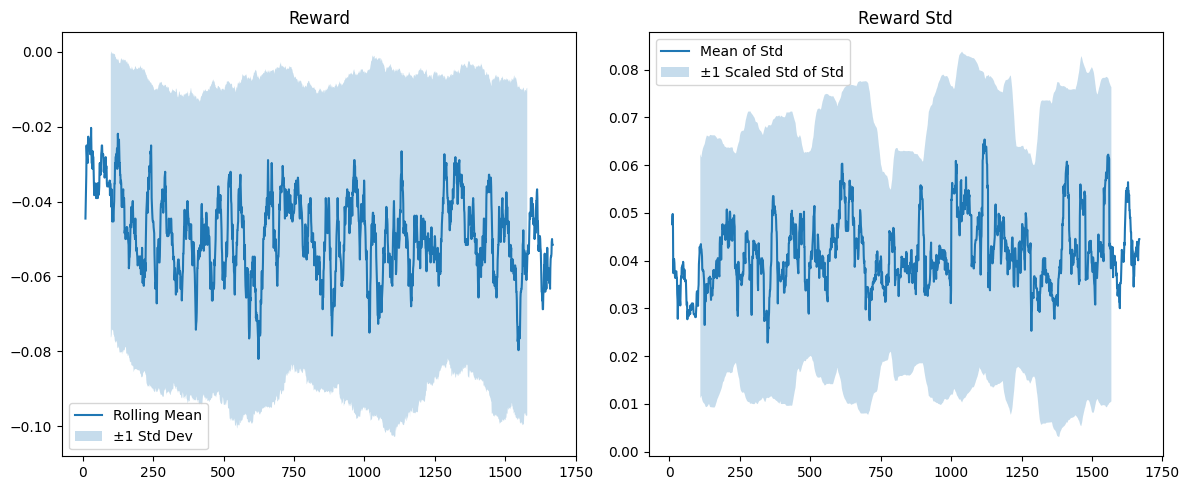

In [27]:
steps = df["step"]
col = df["Reward"]

plt.figure(figsize=(12, 5))

beta = 1
window_size = 20
slow_window = 10 * window_size

plt.subplot(1, 2, 1)
mean = col.rolling(window=window_size, center=True).mean()
std = col.rolling(window=slow_window, center=True).std()
std_mean = col.rolling(window=slow_window, center=True).mean()

plt.plot(steps, mean, label="Rolling Mean")
plt.fill_between(steps, std_mean - beta * std, std_mean + beta * std, alpha=0.25, label=f"±{beta} Std Dev")
plt.title("Reward")
plt.legend()

plt.subplot(1, 2, 2)
window_size = 20
# std_mean = col.rolling(window=window_size, center=True).std()
# std_std_mean = std_mean.rolling(window=10 * window_size, center=True).mean()
# std_std = std_mean.rolling(window=10 * window_size, center=True).std()
std_fast = col.rolling(window=window_size, center=True).std()
std_std_mean = std_fast.rolling(window=slow_window, center=True).mean()
std_std = std_fast.rolling(window=slow_window, center=True).std()
raw_std_std = std_std * np.sqrt(window_size)
lower_bound = np.maximum(0, std_std_mean - beta * raw_std_std)
upper_bound = std_std_mean + beta * raw_std_std

plt.plot(steps, std_fast, label="Mean of Std")
plt.fill_between(steps, lower_bound, upper_bound, alpha=0.25, label=f"±{beta} Scaled Std of Std")
plt.title("Reward Std")
plt.legend()

plt.tight_layout()
plt.show()

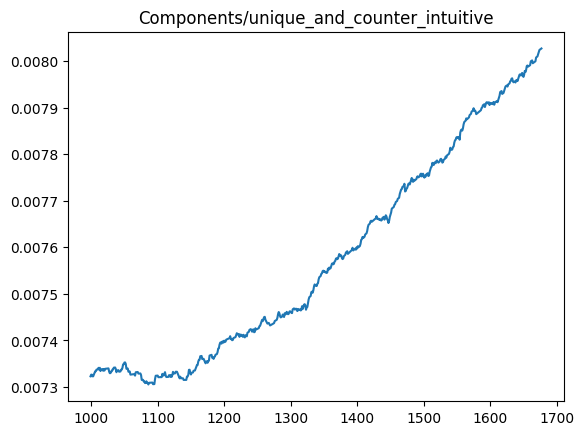

In [16]:
plot_rolling(df["Components/unique_and_counter_intuitive"], 1000)

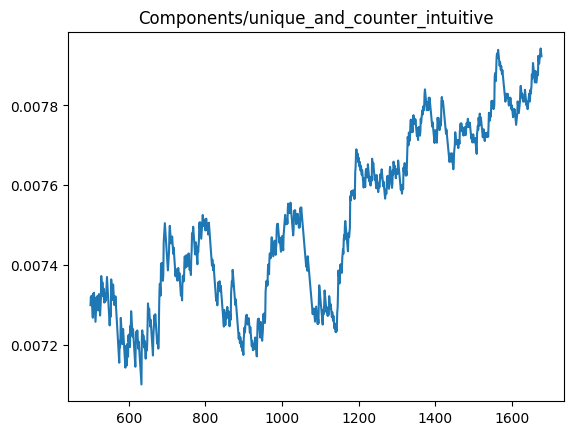

In [23]:
plot_ema(df["Components/unique_and_counter_intuitive"], start=500)

In [239]:
df.columns

Index(['Components/legal_rate', 'step', 'Components/uniqueness_rate',
       'Components/counter_intuitive_rate',
       'Components/counter_intuitive_rate_given_unique',
       'Components/unique_and_counter_intuitive', 'Components/entropy',
       'Components/piece_counts', 'Components/dist_inter_fen',
       'Components/dist_intra_fen', 'Components/dist_inter_pv',
       'Components/dist_intra_pv', 'Components/intra_dist',
       'Components/inter_dist', 'Components/all_dist',
       'Components/pass_diversity_filtering', 'Components/move_match_rate',
       'Components/cp_loss', 'Reward', 'Loss/Total Loss', 'Loss/RL Grad Norm',
       'Loss/KL divergence', 'Loss/Clips', 'Loss/learning_rate'],
      dtype='object')

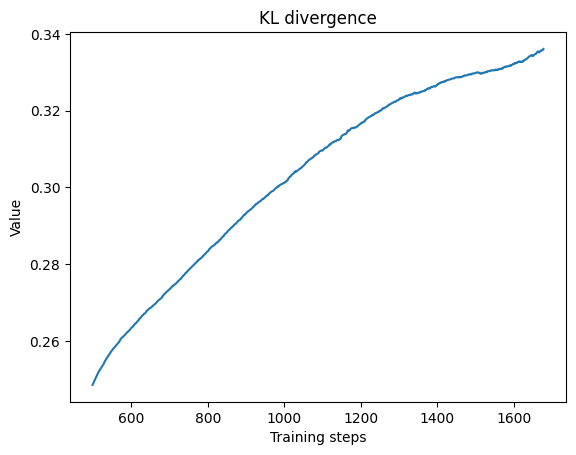

In [24]:
plot_rolling(df["Loss/KL divergence"], window=500)
plt.title("KL divergence")
plt.xlabel("Training steps")
# plt.ylabel("Percentage of positions")
plt.ylabel("Value")
# plt.savefig("./slides/figures/kl_divergence.pdf")
plt.show()

C:\Users\aatus\AppData\Local\Temp\ipykernel_10264\2817206399.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


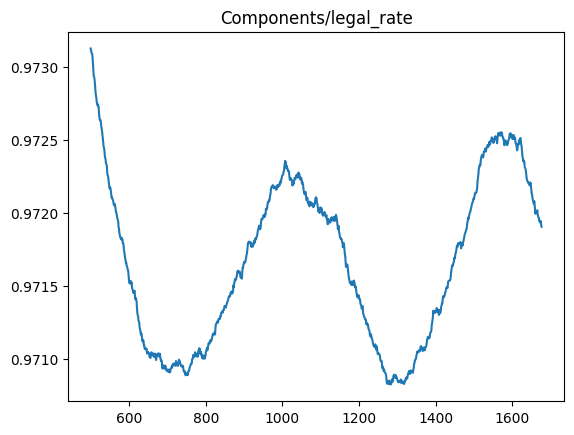

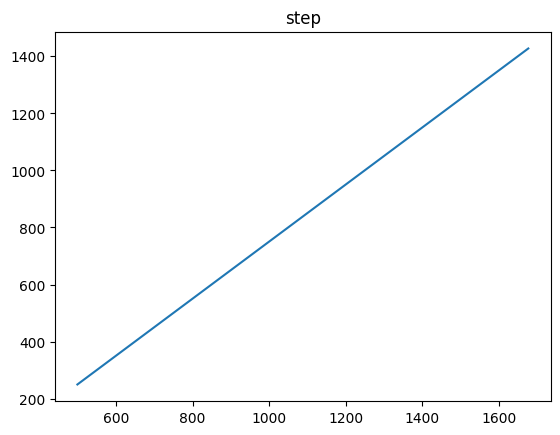

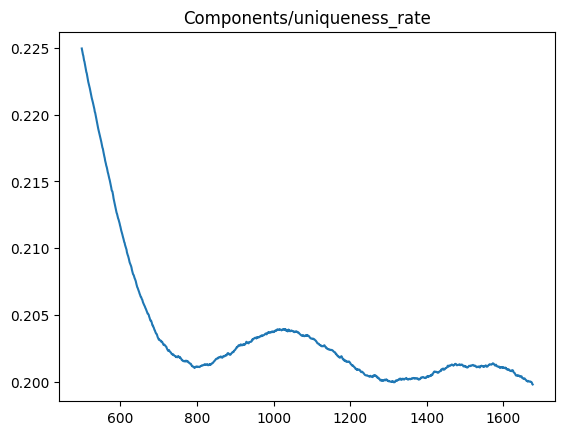

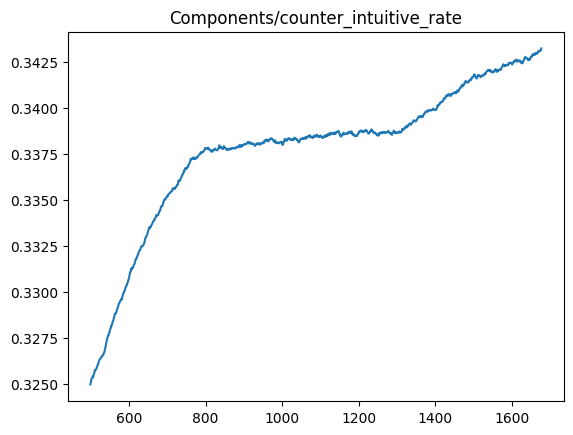

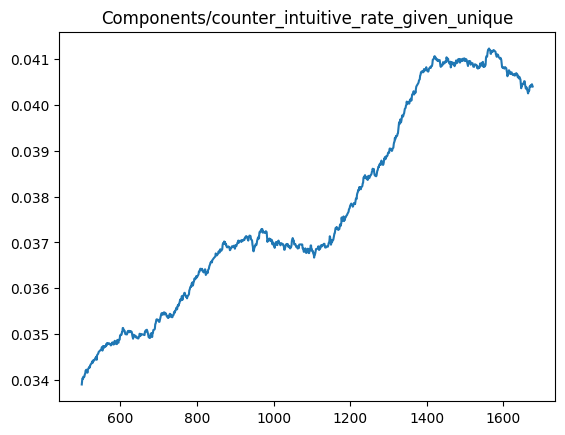

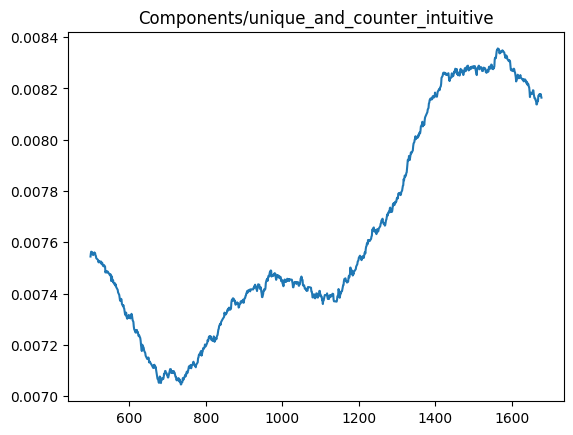

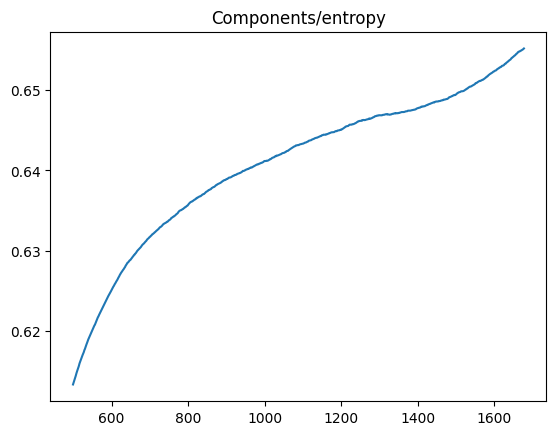

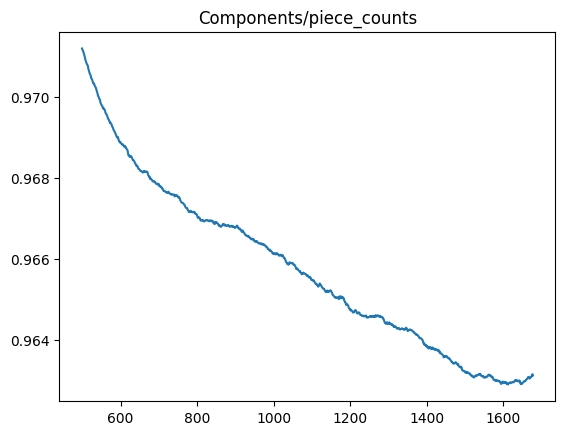

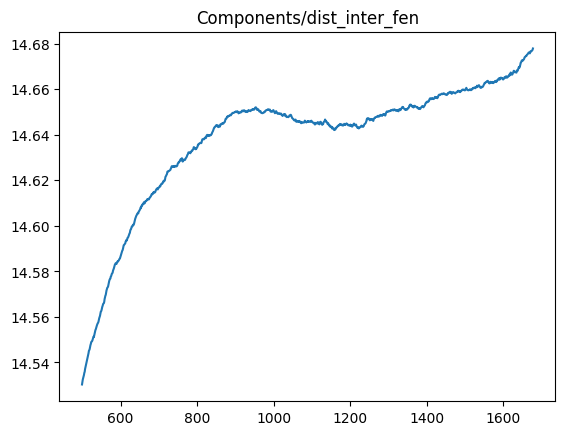

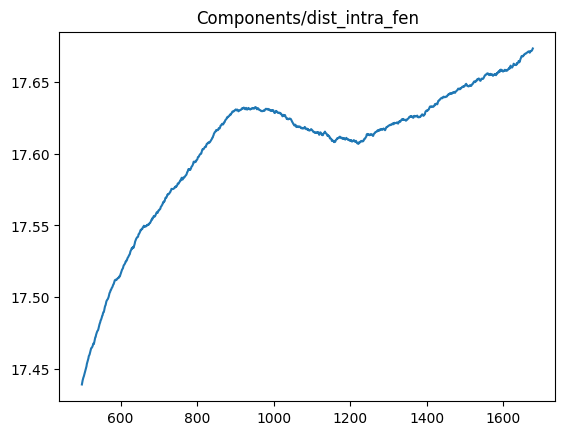

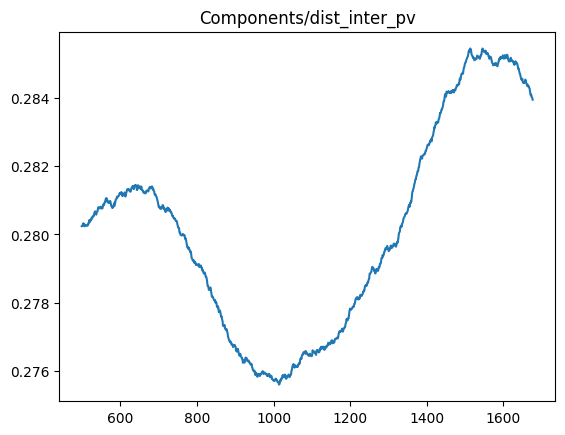

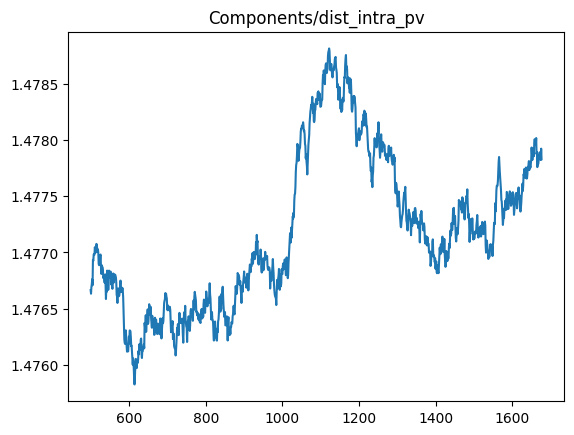

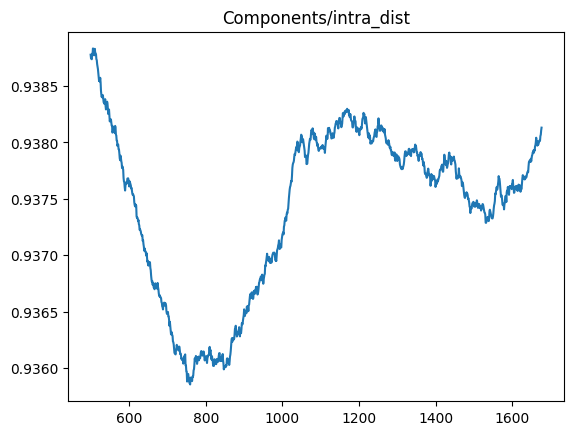

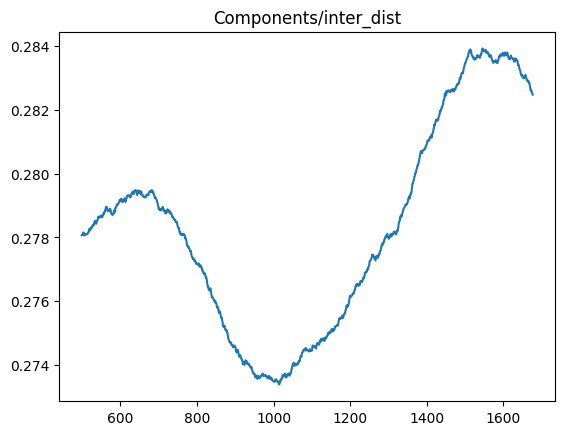

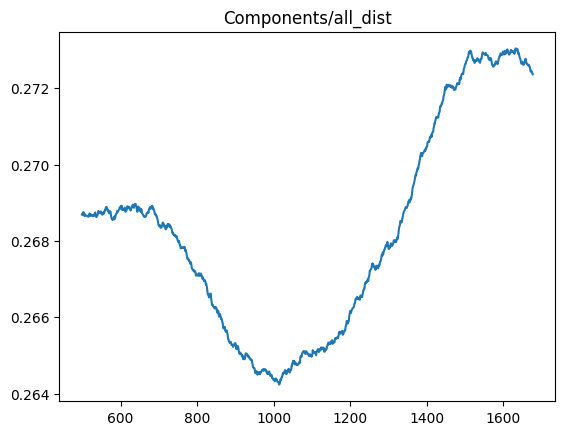

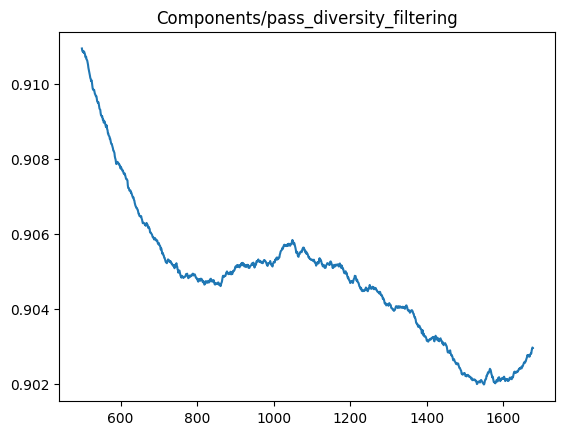

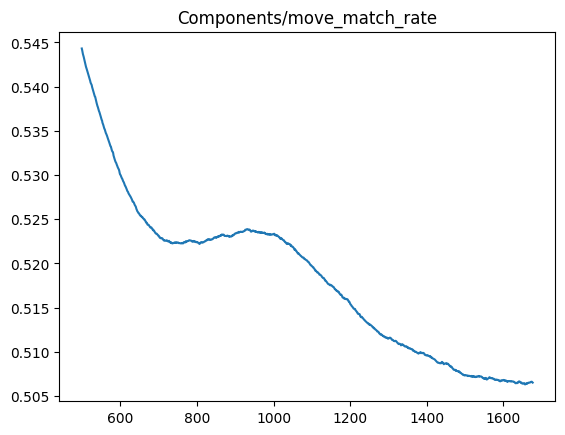

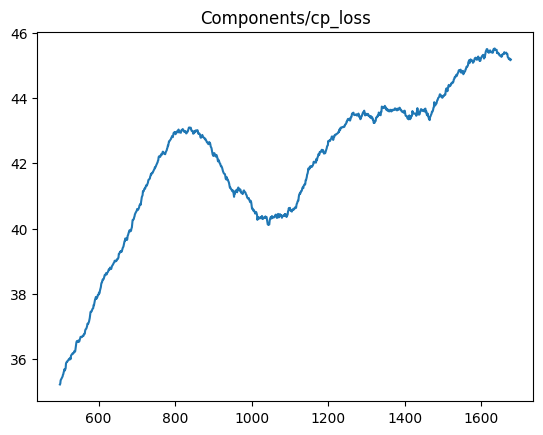

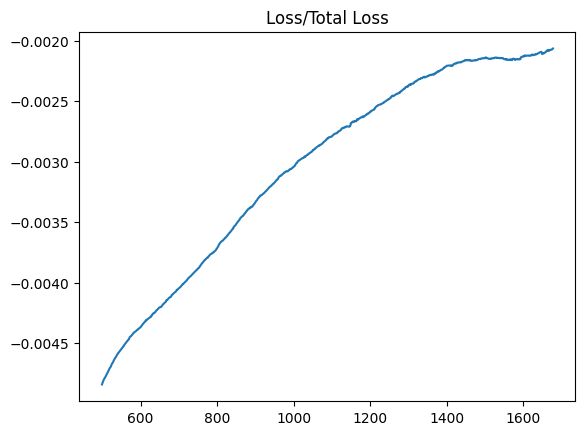

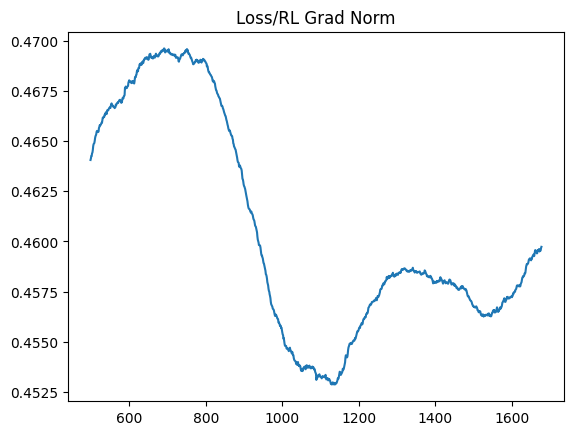

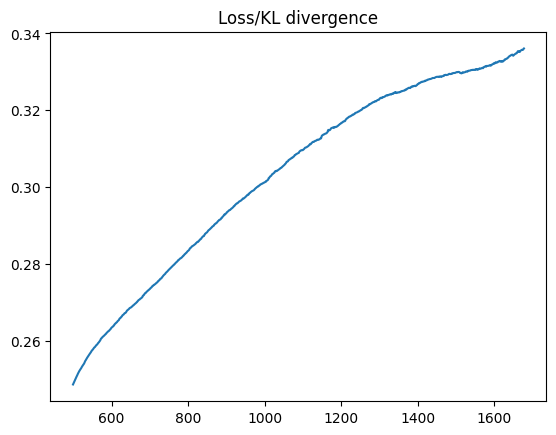

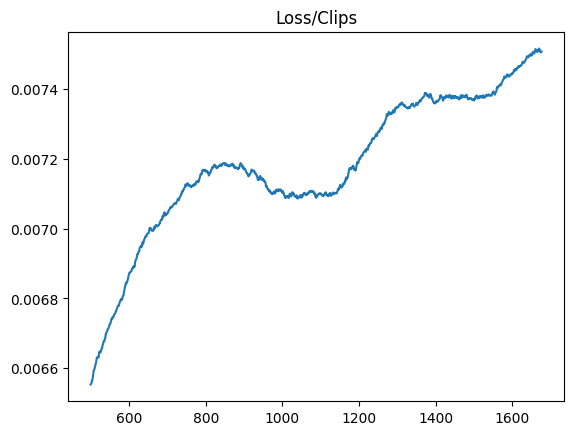

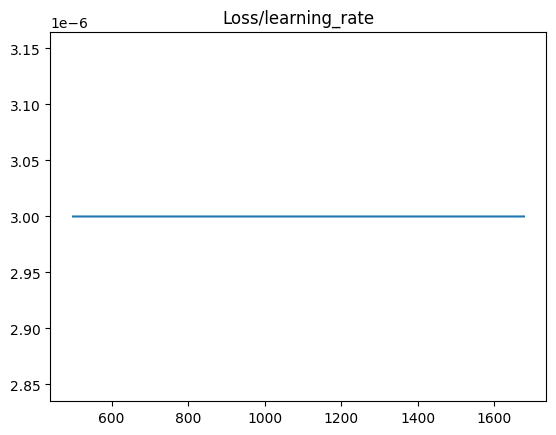

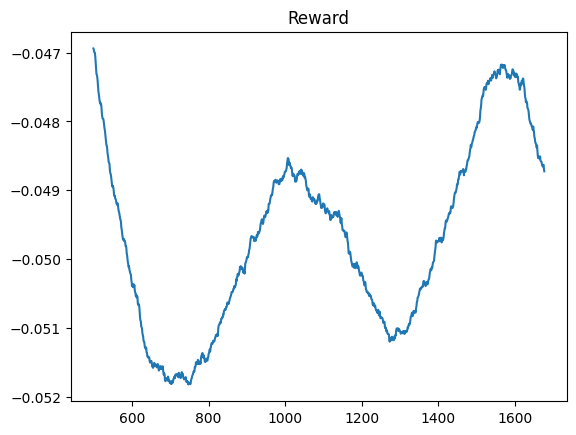

In [25]:
plot_all(df, window=500, type="rolling")